In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re

In [12]:
class Warehouse:
    def __init__(self, layout_image="../Layout/warehouse-layout_clear_1.png", name="WH_Test"):
        self.img = plt.imread(layout_image)
        self.name = name
        self.access_points = {}
        self.edges = []
        self.locations = []
        self.labels = []
    
    def add_location(self, row, bay, cell, position, available=True, access_points=None, metadata=None):
        self.locations.append({
            "_id": f"R{row}_B{bay}_C{cell}",
            "warehouseID": self.name,
            "row": row,
            "bay": bay,
            "cell" : cell,
            "position": position,
            "available": available,
            "access_points" : access_points if access_points else [],
            "metadata": metadata if metadata else {}
        })
    
    def add_access_point(self, ap_id, position):
        self.access_points[ap_id] = {
            "position": position
        }

    def add_edge(self, ap1, ap2):
        p1 = np.array(self.access_points[ap1]["position"])
        p2 = np.array(self.access_points[ap2]["position"])
        self.edges.append({
            "from": ap1,
            "to": ap2,
            "distance": np.linalg.norm(p1 - p2),
            "bidirectional": True
        })

    def add_label(self, label, position, **kwargs):
        self.labels.append({
            "label": label,
            "position": position,
            "metadata": kwargs
        })

    def show_layout(self, fig=None, ax=None):
        if fig is None or ax is None:
            fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(self.img)
        return fig, ax

    def show_locations(self, ax):
        for loc in self.locations:
            if not loc["available"]:
                print(f"Row {loc['row']+1} Bay {loc['bay']} is not available")
                continue
            p = loc["position"]
            ax.plot(p[0], p[1], "bo")

    def show_access_points(self, ax):
        for ap in self.access_points:
            ax.plot(self.access_points[ap]["position"][0], self.access_points[ap]["position"][1], "ro")
            if ap == "Docking":
                ax.text(self.access_points[ap]["position"][0], self.access_points[ap]["position"][1] + 8, ap, fontsize=10, color="red", ha="center", va="top")

    def show_edges(self, ax):
        for edge in self.edges:
            p_from = np.array(self.access_points[edge["from"]]["position"])
            p_to = np.array(self.access_points[edge["to"]]["position"])
            ax.plot([p_from[0], p_to[0]], [p_from[1], p_to[1]], "r--", linewidth=0.5)

    def show_picking_points(self, ax):
        for loc in self.locations:
            if loc["available"] and loc["access_points"]:
                p = loc["position"]
                ax.plot(p[0], p[1], "go")
                for ap in loc["access_points"]:
                    ap_pos = self.access_points[ap]["position"]
                    ax.plot([p[0], ap_pos[0]], [p[1], ap_pos[1]], "g--", linewidth=0.5)

    def show_labels(self, ax):
        for label in self.labels:
            ax.text(label["position"][0], label["position"][1], label["label"], **label["metadata"])


In [13]:
WH = Warehouse()
WH.add_access_point("Docking", [150,570])

bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#f0f0f0",
        edgecolor="#333333",
        linewidth=1.5
    )
for i in range(9):
    WH.add_label(f"R{i+1}", [85 + i * 79, 90], fontsize=10, color="red", ha="left", va="center", bbox=bbox)
for i in range(9,15):
    WH.add_label(f"R{i+1}", [240 + (i-9) * 79, 460], fontsize=10, color="red", ha="left", va="center", bbox=bbox)


###############
sx = 66
sy = 76
dx1 = 79
dx2 = 20

def fill_columns(row, num_columns):
    for i in range(num_columns):
        nbay = 2*(num_columns-i-1)+1
        WH.add_location(
            row=row,
            bay=nbay,
            cell=1,
            position=[sx + (row-1)*dx1, sy + 19 + i * 39],
            available=True,
            access_points=[f"PICK_{row}_{nbay}"]
        )
        WH.add_location(
            row = row,
            bay = nbay,
            cell  = 2,
            position = [sx + row*dx1-dx2, sy + 19 + i * 39],
            available = True,
            access_points = [f"PICK_{row}_{nbay}"]
        )
        WH.add_access_point(f"PICK_{row}_{nbay}", [sx + (row-0.5)*dx1 - dx2/2, sy + 19 + i * 39])
        WH.add_location(
            row = row,
            bay = nbay+1,
            cell = 1,
            position = [sx + (row-1)*dx1, sy + i * 39],
            available = True,
            access_points = [f"PICK_{row}_{nbay+1}"]
        )
        WH.add_location(
            row = row,
            bay = nbay+1,
            cell = 2,
            position = [sx + row*dx1-dx2, sy + i * 39],
            available = True,
            access_points = [f"PICK_{row}_{nbay+1}"]
        )
        WH.add_access_point(f"PICK_{row}_{nbay+1}", [sx + (row-0.5)*dx1 - dx2/2, sy + i * 39])

for row in range(1,3):
    fill_columns(row, 7)
for row in range(3,8):
    fill_columns(row, 8)
for row in range(8,10):
    fill_columns(row, 8)
for nloc,loc in enumerate(WH.locations):
    if loc["row"] == 3 and loc["bay"] in [1,2] and loc["cell"] == 1:
        WH.locations[nloc]["available"] = False


sx = 282
sy = 455

def fill_columns(row, cell, num_columns):
    for nbay in range(num_columns):
        WH.add_location(
            row = row,
            bay = nbay,
            cell = cell,
            position = [sx + 23*(cell-1) + (row-9-cell)*dx1, sy + nbay * 14.5],
            available = True,
            access_points = [f"PICK_{row}_{nbay+1}"]
        )
        WH.add_access_point(f"PICK_{row}_{nbay+1}", [sx +11.5 + (row-10.5)*dx1, sy + nbay * 14.5])


fill_columns(10, 1, 7)
for row in range(11,15):
    fill_columns(row, 1, 7)
    fill_columns(row, 2, 7)
fill_columns(15, 2, 7)

for ap in WH.access_points:
    m = re.match(r"PICK_(\d+)_(\d+)", ap)
    if m:
        row = int(m.group(1))
        bay = int(m.group(2))
        p = np.array(WH.access_points[ap]["position"])
        if f"PICK_{row}_{bay-1}" in WH.access_points:
            WH.add_edge(ap, f"PICK_{row}_{bay-1}")


sx = 96
sy = 368

for row in range(1,3):
    WH.add_access_point(f"AP_{row}", [sx + (row-1)*dx1, sy])
    WH.add_edge(f"AP_{row}", f"PICK_{row}_1")
WH.add_edge("AP_1", "AP_2")
WH.add_edge("AP_2", "PICK_3_1")

sy = 420
for row in range(3,10):
    WH.add_access_point(f"AP_{row}", [sx + (row-1)*dx1, sy])
    WH.add_edge(f"AP_{row}", f"PICK_{row}_1")
    if f"PICK_{row+7}_1" in WH.access_points:
        WH.add_edge(f"AP_{row}", f"PICK_{row+7}_1")
    if row > 3:
        WH.add_edge(f"AP_{row}", f"AP_{row-1}")

sy = 570
for row in range(3,9):
    WH.add_access_point(f"AP_{row+7}", [sx + (row-1)*dx1, sy])
    WH.add_edge(f"AP_{row+7}", f"PICK_{row}_7")
    if row > 3:
        WH.add_edge(f"AP_{row+7}", f"AP_{row+6}")
WH.add_edge("AP_10", "Docking")



Row 4 Bay 1 is not available
Row 4 Bay 2 is not available


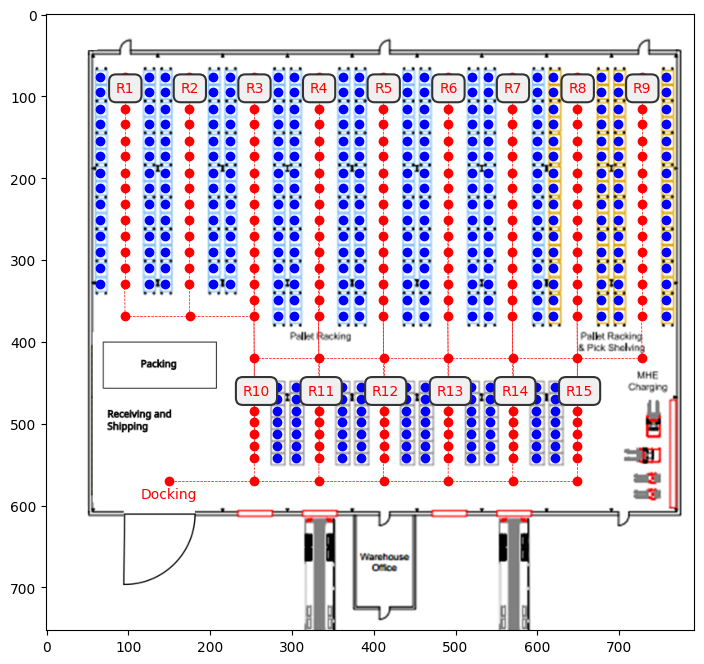

In [14]:
fig,ax = WH.show_layout()
WH.show_locations(ax)
WH.show_access_points(ax)
WH.show_edges(ax)
WH.show_labels(ax)